In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

d:\App\python\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
def load_dataset(data_dir, split="train"):
    X, y = [], []
    classes = ["fresh", "rotten"]

    for label, cls in enumerate(classes):
        folder = os.path.join(data_dir, split, cls)

        for file in os.listdir(folder):
            if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                X.append(os.path.join(folder, file))
                y.append(label)

    return np.array(X), np.array(y)

DATA_DIR = "D:/Do_An/Data_Final"

X_paths, y = load_dataset(DATA_DIR, "train")

print("Total:", len(X_paths))
print("Fresh:", np.sum(y==0))
print("Rotten:", np.sum(y==1))

Total: 1874
Fresh: 920
Rotten: 954


In [3]:
def load_images(paths):
    X = []
    for p in paths:
        img = load_img(p, target_size=(224,224))
        img = img_to_array(img)
        X.append(img)
    return np.array(X, dtype="float32")

X = load_images(X_paths)
X = preprocess_input(X)

print("Shape:", X.shape)

Shape: (1874, 224, 224, 3)


In [4]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

features = base_model.predict(X, batch_size=32, verbose=1)

print("Feature shape:", features.shape)

59/59 ━━━━━━━━━━━━━━━━━━━━ 43s 690ms/step
Feature shape: (1874, 1280)


In [5]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

In [6]:
param_grid = {
    "svm__C": [0.1, 1, 10],
    "svm__kernel": ["rbf"],
    "svm__gamma": ["scale", "auto"]
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,                # 🔥 K-Fold
    scoring="accuracy",
    verbose=2,
    n_jobs=-1
)

grid.fit(features, y)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,estimator,"Pipeline(step...svm', SVC())])"
,param_grid,"{'svm__C': [0.1, 1, ...], 'svm__gamma': ['scale', 'auto'], 'svm__kernel': ['rbf']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [7]:
print("Best Params:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

Best Params: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best Accuracy: 0.9776


In [8]:
results = grid.cv_results_

for mean, params in zip(results["mean_test_score"], results["params"]):
    print(f"{mean:.4f} | {params}")

0.9264 | {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
0.9264 | {'svm__C': 0.1, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}
0.9755 | {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
0.9755 | {'svm__C': 1, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}
0.9776 | {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
0.9776 | {'svm__C': 10, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}


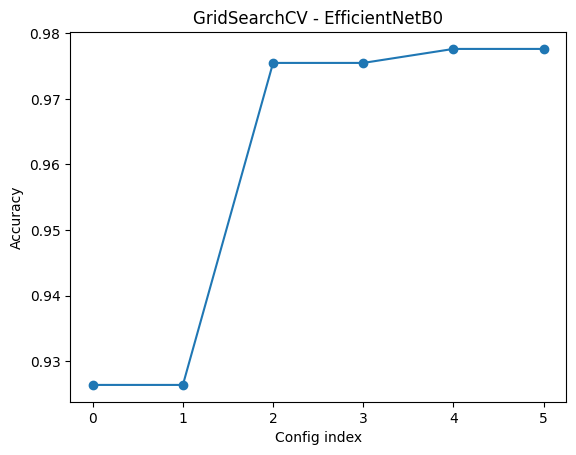

In [9]:
scores = results["mean_test_score"]

plt.figure()
plt.plot(scores, marker='o')
plt.title("GridSearchCV - EfficientNetB0")
plt.ylabel("Accuracy")
plt.xlabel("Config index")
plt.show()

In [10]:
X_test_paths, y_test = load_dataset(DATA_DIR, "test")
X_test = load_images(X_test_paths)
X_test = preprocess_input(X_test)
features_test = base_model.predict(X_test, batch_size=32)
y_pred = grid.best_estimator_.predict(features_test)
from sklearn.metrics import accuracy_score

acc_test = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 628ms/step
Test Accuracy: 0.9945872801082544
